In [1]:
import numpy as np #For the array functions
import tensorflow as tf
from tensorflow import keras #we will only be using tensorflow as a backend, so we will import keras via their implementation
from tensorflow.keras import layers, models #we will use the readable keras implementation of the conv/reccurent layers

import io
import os
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import h5py
from sklearn.model_selection import train_test_split


(479, 640)


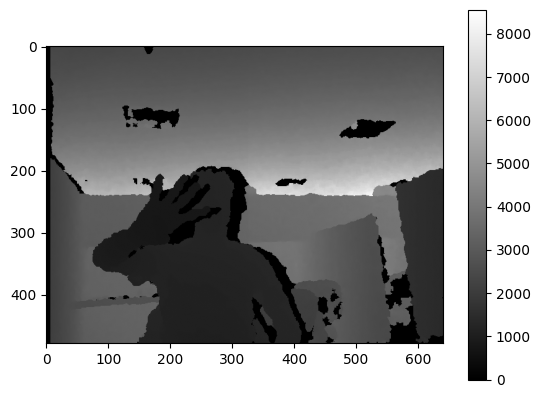

802.0


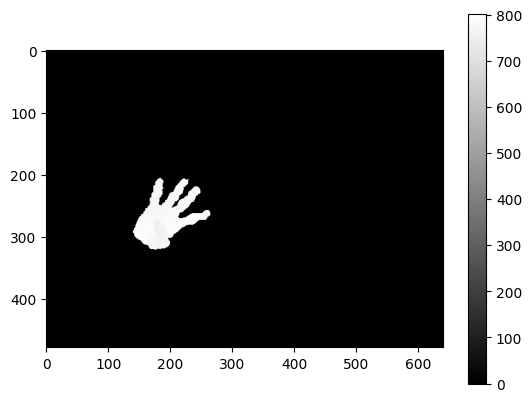

186 341 120 284
801.84485


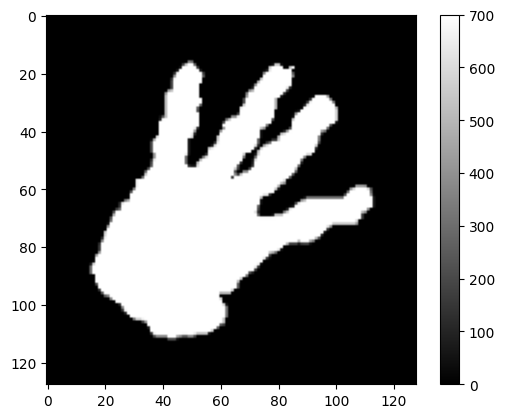

In [3]:
depthMap = pd.read_csv('Depth Images/P2/G5/1.txt')
print(depthMap.shape)
plt.imshow(depthMap, cmap='gray')
plt.colorbar()
plt.savefig("Image1")
plt.show()#depthArray = depthArray.reshape((480, 640))

k = 0
threshold = (np.min(depthMap[depthMap>k])) + 50
print(threshold)

depth = np.array(depthMap, dtype=np.float32)
#depth[depth == 0] = np.nan
depth[depth > threshold] = 0


plt.imshow(depth, cmap='gray')
plt.colorbar()
plt.savefig("Image2")
plt.show()

mask = depth > 0
mask = mask.astype(np.uint8)


num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)
largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])

clean_mask = (labels == largest_label).astype(np.uint8)

depth = depth * clean_mask
ys, xs = np.where(depth>0)


padding = 20

ymin, ymax = max(0, ys.min() - padding), max(0, ys.max() + padding)
xmin, xmax = max(0, xs.min() - padding), max(0, xs.max() + padding)

print(ymin, ymax, xmin, xmax)
hand_crop = depth[ymin:ymax, xmin:xmax]
hand_crop = cv2.resize(hand_crop, (128, 128))

print(hand_crop.max())
plt.imshow(hand_crop, cmap='gray')
plt.clim(0, 700)
plt.colorbar()
plt.savefig("Image3")
plt.show()


In [2]:


def imagePreProcess(depthMap, label):
    depth = np.array(depthMap, dtype=np.float32)
    k = 0
    threshold = (np.min(depthMap[depthMap>k])) + 75

    #depth = np.array(depthMap, dtype=np.float32)
    depth[depth > threshold] = 0

    mask = depth > 0
    mask = mask.astype(np.uint8)

    #labels, stats = cv2.connectedComponentsWithStats(mask)
    #largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])

    #clean_mask = (labels == largest_label).astype(np.uint8)

    #depth = depth * clean_mask

    ys, xs = np.where(depth>0)

    padding = 20

    ymin, ymax = max(0, ys.min() - padding), max(0, ys.max() + padding)
    xmin, xmax = max(0, xs.min() - padding), max(0, xs.max() + padding)


    hand_crop = depth[ymin:ymax, xmin:xmax]
    hand_crop = cv2.resize(hand_crop, (128, 128))

    allImages.append(hand_crop)
    allLabels.append(label)

    #print(hand_crop.max())
    #plt.imshow(hand_crop, cmap='gray')
    #plt.clim(0, 800)
    #plt.colorbar()
    #plt.show()

def createFile():
    with h5py.File("gesture_dataset.h5", "w") as f:
        f.create_dataset("images", data=allImages, compression="gzip")
        f.create_dataset("labels", data=allLabels)

def main():

    # List of directories
    for root, dirs, files in os.walk("Depth Images"):
        path = root.split(os.sep)
        fileNames = []

        allImages = []
        allLabels = []
        print(path)
        for file in files:
            fileNames.append(file)
        
        if (len(fileNames) > 0):
            for index, file in enumerate(files):
                curFile = fileNames[index]
                filePath = (os.path.join(root, curFile))
                
                depthMap = pd.read_csv(filePath)
                #label = curFile.split('.')[0]
                label = int(path[len(path)-1].split('G')[1]) - 1
                print(label)
                depthMap = np.array(depthMap, dtype=np.float32)
                imagePreProcess(depthMap, label)

                flippedDepthMap = np.flip(depthMap, axis=1)
                imagePreProcess(flippedDepthMap, label)
    createFile()

allImages = []
allLabels = []
main()
        


['Depth Images']
['Depth Images', 'P1']
['Depth Images', 'P1', 'G1']
0
0
0
0
0
0
0
0
0
0
['Depth Images', 'P1', 'G10']
9
9
9
9
9
9
9
9
9
9
['Depth Images', 'P1', 'G2']
1
1
1
1
1
1
1
1
1
1
['Depth Images', 'P1', 'G3']
2
2
2
2
2
2
2
2
2
2
['Depth Images', 'P1', 'G4']
3
3
3
3
3
3
3
3
3
3
['Depth Images', 'P1', 'G5']
4
4
4
4
4
4
4
4
4
4
['Depth Images', 'P1', 'G6']
5
5
5
5
5
5
5
5
5
5
['Depth Images', 'P1', 'G7']
6
6
6
6
6
6
6
6
6
6
['Depth Images', 'P1', 'G8']
7
7
7
7
7
7
7
7
7
7
['Depth Images', 'P1', 'G9']
8
8
8
8
8
8
8
8
8
8
['Depth Images', 'P10']
['Depth Images', 'P10', 'G1']
0
0
0
0
0
0
0
0
0
0
['Depth Images', 'P10', 'G10']
9
9
9
9
9
9
9
9
9
9
['Depth Images', 'P10', 'G2']
1
1
1
1
1
1
1
1
1
1
['Depth Images', 'P10', 'G3']
2
2
2
2
2
2
2
2
2
2
['Depth Images', 'P10', 'G4']
3
3
3
3
3
3
3
3
3
3
['Depth Images', 'P10', 'G5']
4
4
4
4
4
4
4
4
4
4
['Depth Images', 'P10', 'G6']
5
5
5
5
5
5
5
5
5
5
['Depth Images', 'P10', 'G7']
6
6
6
6
6
6
6
6
6
6
['Depth Images', 'P10', 'G8']
7
7
7
7
7
7
7


In [ ]:
with h5py.File('gesture_dataset.h5', 'r') as file:
    print(file)
    a_group_key = list(file.keys())[1]
    data = list(file[a_group_key])

    X = file['images'][:]
    y = file['labels'][:]    
    # Getting the data

X = np.array([depthImage / X.max() for depthImage in X])
y = np.array([label for label in y])

X = np.expand_dims(X, axis=-1)

#X = X.reshape(None, 1000, 128, 128)
#X = np.expand_dims(X, axis=-1)

train_images, test_images, train_labels, test_labels = train_test_split(
    X, y, test_size=0.25, random_state=42)

print(train_images.shape)
print(train_images.dtype)
print(train_images.min(), train_images.max())


data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.04),
    layers.RandomZoom(0.05)
])

model = models.Sequential()
#model.add(data_augmentation)
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))

model.summary()

model.add(layers.Flatten()) 
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.3))
#model.add(layers.Dense(10))
#model.add(layers.Dense(128, kernel_regularizer = regularizers.l2(l = 0.016),activity_regularizer=regularizers.l1(0.006),
#                    bias_regularizer=regularizers.l1(0.006) ,activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'],
              )

history = model.fit(train_images, train_labels, epochs=60, batch_size = 16,
                    validation_data=(test_images, test_labels))

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(test_acc)
"""

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'],
              )

history = model.fit(train_images, train_labels, epochs=60, batch_size = 16,
                    validation_data=(test_images, test_labels))
"""

<HDF5 file "gesture_dataset.h5" (mode r)>
(1500, 128, 128, 1)
float32
0.0 1.0


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 512)      │     1,180,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,568,000 (5.98 MB)

 Trainable params: 1,568,000 (5.98 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.1107 - loss: 2.3021 - val_accuracy: 0.2400 - val_loss: 2.2298
Epoch 2/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.3373 - loss: 1.8519 - val_accuracy: 0.6280 - val_loss: 1.1731
Epoch 3/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.6193 - loss: 1.1137 - val_accuracy: 0.8100 - val_loss: 0.6882
Epoch 4/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - accuracy: 0.7413 - loss: 0.7205 - val_accuracy: 0.8560 - val_loss: 0.4837
Epoch 5/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - accuracy: 0.8193 - loss: 0.5267 - val_accuracy: 0.8980 - val_loss: 0.3397
Epoch 6/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.8580 - loss: 0.3882 - val_accuracy: 0.9020 - val_loss: 0.3171
Epoch 7/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.8793 - loss: 0.3246 - val_accuracy: 0.9280 - val_loss: 0.2463
Epoch 8/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.9067 - loss: 0.2452 - val_accuracy: 0.8960 - v

"\n\nmodel = models.Sequential()\nmodel.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 1)))\nmodel.add(layers.MaxPooling2D((2, 2)))\nmodel.add(layers.Conv2D(64, (3, 3), activation='relu'))\nmodel.add(layers.MaxPooling2D((2, 2)))\nmodel.add(layers.Conv2D(64, (3, 3), activation='relu'))\n\nmodel.add(layers.Flatten())\nmodel.add(layers.Dense(64, activation='relu'))\nmodel.add(layers.Dropout(0.3))\nmodel.add(layers.Dense(10, activation='softmax'))\n\nmodel.compile(optimizer='adam',\n              loss='sparse_categorical_crossentropy',\n              metrics=['accuracy'],\n              )\n\nhistory = model.fit(train_images, train_labels, epochs=60, batch_size = 16,\n                    validation_data=(test_images, test_labels))\n"

16/16 - 1s - 32ms/step - accuracy: 0.9340 - loss: 0.5673
0.9340000152587891


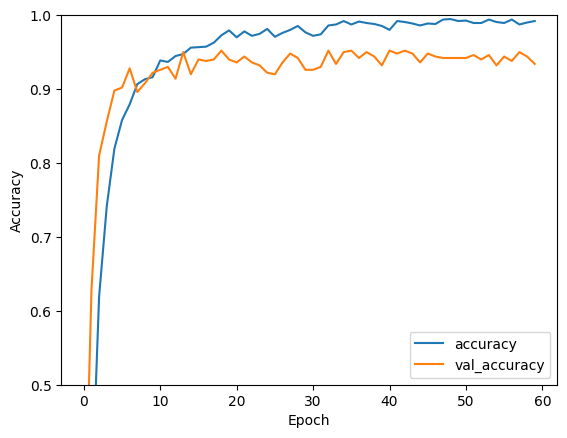

In [6]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(test_acc)

In [7]:
model.save("my_model.h5", include_optimizer=True)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step


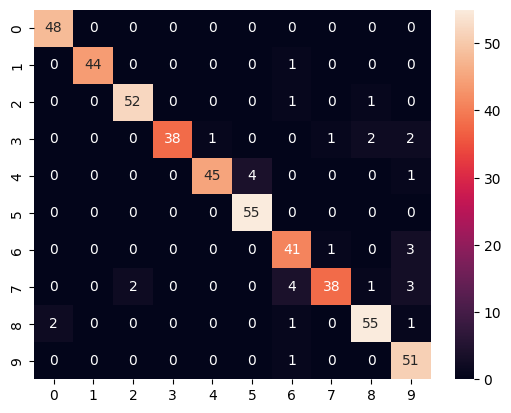

In [8]:
predictions = model.predict(test_images)
predicted_classes = np.argmax(predictions, axis=1)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(test_labels, predicted_classes)
sns.heatmap(cm, annot=True)
plt.show()